## Impotando pacotes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from scipy.stats import skew , kurtosis
import time

# importando o framework hibrido

In [2]:
sys.path.append(os.path.abspath("../src"))

In [3]:
from populacao import Populacao
from pygenec.selecao.torneio import Torneio
from pygenec.cruzamento.edge_recombination import Edge_recombination
from pygenec.cruzamento.unponto import UmPonto

from pygenec.mutacao.inversion import Inversion
from pygenec.mutacao.swap import Swap

from pygenec.busca_local.opt_2 import Opt_2

from evolucao import Evolucao
from evolucao_tsp_classico import Evolucao_classica

from funcoes import Criar_Gif, Imagens_para_gif,Ate_convergir, Melhor_rota

## Importando cordenadas csv

In [4]:
sys.path.append(os.path.abspath("../data"))

In [5]:
small = pd.read_csv(r"../data/kangle/small.csv",encoding= 'utf-8', sep=',', names= ['x','y'])
medium = pd.read_csv(r"../data/kangle/medium.csv",encoding= 'utf-8', sep=',', names= ['x','y'])
large = pd.read_csv(r"../data/kangle/large.csv",encoding= 'utf-8', sep=',', names= ['x','y'])

## Algoritmo

In [6]:
def adjacencias (dataframe):
    dist = []
    for i in range(len(dataframe.index)):
        linhas = []
        for j in range(len(dataframe.index)):
            soma = ((dataframe.x[i]-dataframe.x[j])**2) + ((dataframe.y[i]-dataframe.y[j])**2)
            raiz = soma**(1/2)
            linhas.append(raiz)
        dist.append(linhas)
    
    return dist


def fun(individuo):
    f = 0
    n = len(individuo)
    for i in range(n-1):
        local1 = individuo[i]
        local2 = individuo[i+1]
        distancia = dist[local1][local2]
        f += distancia
    f+= dist[individuo[-1]][individuo[0]]
    return f

def avaliacao(populacao):
    tpm = []
    for ind in populacao:
        tpm.append(fun(ind))
    tpm = np.asarray(tpm)
    return tpm

In [7]:
np.random.seed(12)

## Small

In [8]:
dist = adjacencias(small)

### hiperparâmetros

In [9]:
cromossos_totais = len(small)
tamanho_populacao = 50
geracao = 100
Valor_otimizador = 0.10
pmut = 0.3

### algoritmo hibrido

In [10]:
Nome = "AG Híbrido"
tam = "Small"
Juncao = Nome +" " +tam

In [11]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao = Torneio(populacao)
cruzamento = Edge_recombination(tamanho_populacao)
mutacao = Inversion(pmut)
otimizador = Opt_2(dist)
evolucao = Evolucao(populacao,selecao,
                    cruzamento,mutacao,
                    otimizador,
                    Valor_otimizador,
                    geracao)

evolucao.nsele = 30
evolucao.pcruz = 0.8

In [12]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 217.21 | Melhor rota: [29  9  6 11 26 21 24 12  7 25 22 18  5  3 28  0 20 15  2 10 27 17 19  8
 14 16 13  4 23  1]
Geração   2 | Melhor fitness: 202.52 | Melhor rota: [29 14 16  9  6  0 28  3 19  8  7 12 24 21 22 25 15 20 23  4 13 18  5  2
 10 26 11 17 27  1]
Geração   3 | Melhor fitness: 202.52 | Melhor rota: [17 19  6 13  3  5  1 29  9 12  7  8  0 28 21 24 16 14 23 11 26 18  2  4
 25 22 27 10 15 20]
Geração   4 | Melhor fitness: 186.37 | Melhor rota: [17 19  6 13  3  5  1 29  9 12  7  8  0 28 21 24 16 14 23 11 26 18  2  4
 25 22 27 10 15 20]
Geração   5 | Melhor fitness: 170.31 | Melhor rota: [17 12  7 28  0  6 22 25  2 26 18 14 23  4 21 24  8 19 27 10 15  3 20  9
 29  1  5 11 16 13]
Geração   6 | Melhor fitness: 152.05 | Melhor rota: [24 21  8 19 27 22 25  4  2 18 14 23  1  5 11 26 10 15  3 13 16  9 20 29
  7 12 17  6  0 28]
Geração   7 | Melhor fitness: 152.05 | Melhor rota: [19 28  2 26 11  5  1 23 17 21  8 24 12  7  4 29 10 18 14 27 22  6  0 16
 13 2

In [13]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)

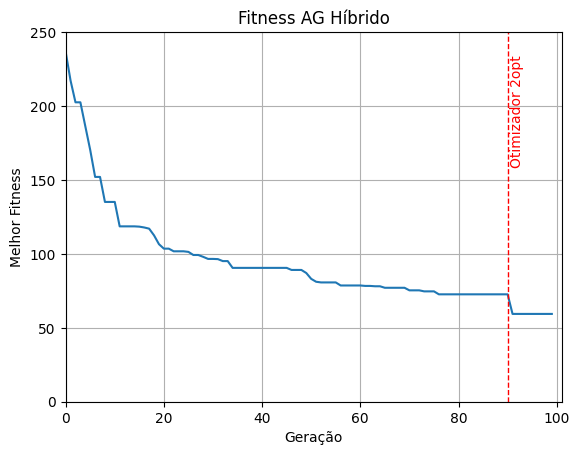

In [14]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")
linha_otmizador = geracao - (geracao*Valor_otimizador)

plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, 250)
plt.xlim(0, geracao + 1)
plt.axvline(x=linha_otmizador, color='r', linestyle='--', linewidth=1)
plt.text(linha_otmizador + 0.5, 160, 'Otimizador 2opt', rotation=90, color='red')
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [15]:
Imagens_para_gif(evolucao,small,tamanho_populacao,Nome)
ROOT = os.path.abspath(os.path.join(".."))
INPUT = os.path.join(ROOT, "outputs", "imagens", "*.png")
OUTPUT = os.path.join(ROOT, "outputs", "gifs", f"{Juncao}.gif")
Criar_Gif(INPUT, OUTPUT)
Melhor_rota(evolucao,small,tamanho_populacao,Juncao,Nome)

Resultados

In [16]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("="*40)


RESULTADOS - AG Híbrido
Assimetria:             2.1668
Curtose:                5.0269
Desvio padrão:          33.9159
Tempo de execução:      7.11 s
Gerações até convergir: 91
----------------------------------------
Melhor fitness:         59.3890
Melhor rota encontrada:
[24 11 14  2 18  5 23 26  1 10 27 22 29  9  6 19  0 13  4 20 28  3  7 25
 15 21 16 17  8 12]


### Algoritimo classico

In [17]:
Nome = "AG Clássico"
tam = "Small"
Juncao = Nome +" " +tam

In [18]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao= Torneio(populacao)
cruzamento = UmPonto(tamanho_populacao)
mutacao = Swap(pmut)
evolucao = Evolucao_classica(populacao,selecao,
                    cruzamento,mutacao)

evolucao.nsele = 30
evolucao.pcruz = 0.8

In [19]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 213.53 | Melhor rota: [ 7  8  5 11 26  4 20 15 28  6  9 10 24 13 29  2 23 19 22 21  3 25  1 18
 27  0 12 17 16 14]
Geração   2 | Melhor fitness: 203.07 | Melhor rota: [ 1 27 24  9  6 12 17 25 28 29  4 19  5 20 14 18 21 16  7  8  0  3 15 26
  2 11 23 13 22 10]
Geração   3 | Melhor fitness: 182.67 | Melhor rota: [14 23  0 18  5  2 26  1 27 24  9  6 12 17 25 28 29  4 19 22 10 21  7  8
 11 13 16 15  3 20]
Geração   4 | Melhor fitness: 182.67 | Melhor rota: [ 1 27 24  9  6 12 17 25 28 29  4 19  3 10 18 15  7 16 22 20 14  2 23 26
  5  0 13  8 21 11]
Geração   5 | Melhor fitness: 171.12 | Melhor rota: [ 1 27 24  9  6 12 17 25 28 29  4 19  3 10 18 15  7 16 22 20 14  2 23 26
  5  0 13  8 21 11]
Geração   6 | Melhor fitness: 171.12 | Melhor rota: [14 23  0 18  5  2 26  1 27 24  9  6 12 17 25 28 29  4 19 22 10 21  7 16
  3 13 20 15  8 11]
Geração   7 | Melhor fitness: 168.37 | Melhor rota: [14 23  0 18  5  2 26  1 27 24  9  6 12 17 25 28 29  4 19 22 10 21  7 16
  3 1

In [20]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)

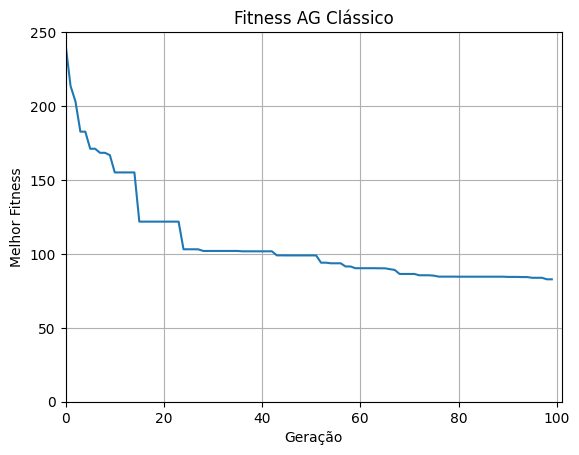

In [21]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")
linha_otmizador = geracao - (geracao*Valor_otimizador)

plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, 250)
plt.xlim(0, geracao + 1)
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [22]:
Melhor_rota(evolucao,small,tamanho_populacao,Juncao,Nome)

Resultados

In [23]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("="*40)


RESULTADOS - AG Clássico
Assimetria:             1.9742
Curtose:                3.5248
Desvio padrão:          32.2115
Tempo de execução:      3.36 s
Gerações até convergir: 98
----------------------------------------
Melhor fitness:         82.8056
Melhor rota encontrada:
[27 14  2 23  5 18 11 26  1 10 15 12 24  3 22 29  9  6  0 13  4  7 25 21
 16  8 17 20 19 28]


## Medium

In [24]:
dist = adjacencias(medium)

### Hiperparâmetros

In [25]:
cromossos_totais = len(medium)
tamanho_populacao = 200
geracao = 200
Valor_otimizador = 0.10
pmut = 0.3

### Algoritmo híbrido

In [26]:
Nome = "AG Híbrido"
tam = "Medium"
Juncao = Nome +" " +tam

In [27]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao = Torneio(populacao)
cruzamento = Edge_recombination(tamanho_populacao)
mutacao = Inversion(pmut)
otimizador = Opt_2(dist)
evolucao = Evolucao(populacao,selecao,
                    cruzamento,mutacao,
                    otimizador,
                    Valor_otimizador,
                    geracao)

evolucao.nsele = 100
evolucao.pcruz = 0.8

In [28]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 42.02 | Melhor rota: [80 53 30 71 10  0 45 13 14 66 39 65 62 34 96 50 55 46 29  2 64 81 17 52
 95 56 15 33 31 36 48 70  4 99 28 77 16 92 37 89 91  7 74 76 27 42  1 84
 20  8 78 67  6 86 83 26 79 12 93 25 73 72 21 68 49 59 60 69  9 43  5 61
 40 11 54 22 35 57 63 23 85 82  3 75 58 44 94 19 41 47 32 88 38 51 87 18
 98 97 90 24]
Geração   2 | Melhor fitness: 40.60 | Melhor rota: [16 86 51 77 74 67 36 57 78 63 65 87 84 14 61 52 17 69 59 49  4 81 41 28
 60 44 93 38 30 26 75 64  8 21 90 20 96 23  1 80 82 72 94 54 85  5 18 32
 89 66 50 40  7 91 70 73 83 19 11 71 95 46 24 97 12 56 92 39 34 43  3 42
 35 47  2 76 88 31  0 22  9 62 79 53  6 15 68 27 13 99 10 58 98 55 37 48
 33 29 45 25]
Geração   3 | Melhor fitness: 40.60 | Melhor rota: [ 1 24 97 59 49 68 75 11 71 95 46 34 88 31  0  8 64 81  4 12 56 92 39 26
 30 27 13 76  2 47 35 42  3 43 23 19 83 73 70 91  6 15 74 77 51 25 45 29
 33 48 50 40  7 96 37 55 80 82 72 69 98 58 20 99 10 18  5 79 53 54 85 21
 90 16 86 67 36 

In [29]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)

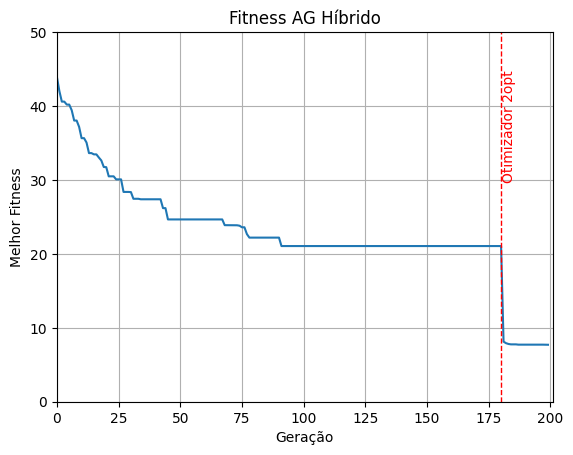

In [30]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")
linha_otmizador = geracao - (geracao*Valor_otimizador)

plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, 50)
plt.xlim(0, geracao + 1)
plt.axvline(x=linha_otmizador, color='r', linestyle='--', linewidth=1)
plt.text(linha_otmizador + 0.5, 30, 'Otimizador 2opt', rotation=90, color='red')
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [31]:
Imagens_para_gif(evolucao,medium,tamanho_populacao,Nome)
ROOT = os.path.abspath(os.path.join(".."))
INPUT = os.path.join(ROOT, "outputs", "imagens", "*.png")
OUTPUT = os.path.join(ROOT, "outputs", "gifs", f"{Juncao}.gif")
Criar_Gif(INPUT, OUTPUT)
Melhor_rota(evolucao,medium,tamanho_populacao,Juncao,Nome)

c:\Users\joaoa\OneDrive\Área de Trabalho\Project_Ag_tsp-20260315T192543Z-3-001\Project_Ag_tsp\src\funcoes.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(pasta, F"{numero+1}.png"),


Resultados

In [32]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("="*40)


RESULTADOS - AG Híbrido
Assimetria:             0.0567
Curtose:                1.4790
Desvio padrão:          6.9662
Tempo de execução:      533.35 s
Gerações até convergir: 198
----------------------------------------
Melhor fitness:         7.7053
Melhor rota encontrada:
[12 27 54 88 63 55  1 43 79 11 78  5 57 16 60 97 71 46 77 53 82 69 45 75
  3 74 59 86 29 67 25 41 72  6 96 93 39 51 26 62 22 91 80  7 49 90  4 13
 95 44 83 68 37 42 33  9 15 34 70 64 58  0 35 92 76 52 40 65 14 38 73 87
 20 18 81 84 17 61  2 10 85  8 50 36 47 31 89 28 32 24 48 23 66 56 98 99
 21 94 30 19]


### Algoritmo clássico

In [33]:
Nome = "AG Clássico"
tam = "Medium"
Juncao = Nome +" " +tam

In [34]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao= Torneio(populacao)
cruzamento = UmPonto(tamanho_populacao)
mutacao = Swap(pmut)
evolucao = Evolucao_classica(populacao,selecao,
                    cruzamento,mutacao)

evolucao.nsele = 100
evolucao.pcruz = 0.8

In [35]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 42.47 | Melhor rota: [46 59  0 68 10 93 57 69 85 24 94 61 23 81 40 76 26 47 91 74 15 60 28  5
  3 72  7 84 77 58 53 41 82 80 20 75 63 66 89 73 44 32 19 99 13 29 49 96
  9  8  4 42 83 98 65 54  1 48 35  2 30 16 51 55 12 92 79 78 22 64 70 90
 71 37 31 17 25 33 27 88  6 34 11 95 43 56 21 38 87 14 39 62 67 86 18 52
 36 50 45 97]
Geração   2 | Melhor fitness: 41.86 | Melhor rota: [46 59  0 68 10 93 57 69 85 24 94 61 23 81 40 76 26 47 91 74 15 60 28  5
  3 72  7 84 77 58 53 41 82 80 20 75 63 66 89 73 44 32 19 99 13 29 49 96
  9  8  4 42 83 98 65 54  1 48 35  2 30 16 51 55 12 92 79 78 22 64 70 90
 71 37 31 17 25 33 27 88  6 34 11 95 43 56 21 38 87 14 39 62 67 86 18 52
 36 50 45 97]
Geração   3 | Melhor fitness: 40.32 | Melhor rota: [67 23 76 77 13 32 31 63  1 87 17 14 44  9 78 82 38 34 60 41 93 81 27 12
  7 99 88 48 42 66 69 62 72 29 51 80 74  3 57 56 47 43 37 90 11 16 70 59
 36 58  0 26 96 61  4 97 79 33  8 24 28 94 30  6 40 53 50 92  2 68 46 49
 15 54 84 85 35 

In [36]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)

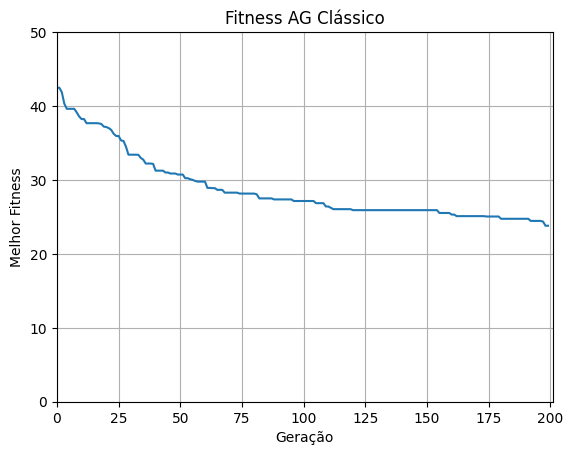

In [37]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")


plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, 50)
plt.xlim(0, geracao + 1)
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [38]:
Melhor_rota(evolucao,medium,tamanho_populacao,Juncao,Nome)

Resultados

In [39]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("="*40)


RESULTADOS - AG Clássico
Assimetria:             1.3362
Curtose:                0.7681
Desvio padrão:          4.4760
Tempo de execução:      22.34 s
Gerações até convergir: 198
----------------------------------------
Melhor fitness:         23.8067
Melhor rota encontrada:
[ 1 24 35  0 58 12 94 10 21 98 31 48 63 27 32 19 17 40 92  9 90 39 37 68
 23 66 54  7 22 62 26 96 51 80 41 82 59 95 11 60 88 47 89 28  8 84 20 76
 64 36 50 33 42  5 78 43 15  4 29 97 46 53 45 77  3 69 71 83 44 99 56 30
 91 73 85 13 74 67 25 86 49 87 38 81 18 14 61  2 34 70 55 79 75 57 16 72
  6 93 65 52]
